In [1]:
!pip install langchain langgraph langchain_openai langchain_groq --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 857.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.7/126.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 7.0 MB/s eta 0:00:00


In [2]:
import os
from google.colab import userdata
#os.environ["OPENAI_API_KEY"]"" = userdata.get('OPEN_API_KEY')
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [3]:
# Import ChatModels
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

# Import Langgraph
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import display, Image

from typing_extensions import TypedDict, Optional, Literal, Optional
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

In [4]:
# Initialize the LLMs
# General purpose LLM for most tasks
llm = ChatGroq(model="qwen-2.5-32b")

# Specialized LLM for code generation
llm_code = ChatGroq(model="qwen-2.5-coder-32b")

In [5]:

# Create a system prompt template for standard operations
standard_system_prompt = """You are an expert software development assistant specialized in the software development lifecycle.
You have deep knowledge of requirements gathering, design, implementation, testing, deployment, and maintenance.
Always provide structured, well-organized responses.
"""

# Create a system prompt template specifically for code generation
code_system_prompt = """You are an expert software engineer with deep knowledge of software design patterns, clean code principles, and secure coding practices.
When writing code, ensure it is:
- Well-structured and follows language-specific best practices
- Well-documented with comments
- Error-handled appropriately
- Security-focused
- Performance-optimized
- Testable
"""

In [6]:
# Initialize chains
standard_prompt = ChatPromptTemplate.from_messages([
    ("system", standard_system_prompt),
    ("human", "{input}")
])

code_prompt = ChatPromptTemplate.from_messages([
    ("system", code_system_prompt),
    ("human", "{input}")
])

standard_chain = standard_prompt | llm | StrOutputParser()
code_chain = code_prompt | llm_code | StrOutputParser()

In [7]:
# Initialize the state
class State(TypedDict):
    requirements: str
    user_stories: list
    design_doc: dict
    product_feedback: str
    code_feedback: str
    code: str
    test_cases: list
    qa_result: Literal["Passed", "Failed"]
    feedback: str
    review_user_story_count: int
    review_product_design_count: int
    review_code_count: int


In [8]:
# Node 1: Auto-generate User Stories
def auto_generate_user_stories(state: State) -> State:
    """Generate well-structured user stories based on requirements."""

    user_stories_prompt = f"""
    Based on the following requirements, generate comprehensive user stories:

    REQUIREMENTS:
    {state['requirements']}

    Please generate user stories that:
    1. Follow the standard format: "As a [type of user], I want [action/goal] so that [benefit/value]"
    2. Include acceptance criteria for each story
    3. Assign story points (complexity estimation) on a scale of 1-13
    4. Add a priority level (Critical, High, Medium, Low)
    5. Include a unique ID for each story (e.g., US-001)
    6. Group related stories together

    The output should be structured as follows:

    ## User Story: [ID]
    **As a** [type of user]
    **I want** [action/goal]
    **So that** [benefit/value]

    **Priority:** [priority level]
    **Story Points:** [points]

    **Acceptance Criteria:**
    1. [criterion 1]
    2. [criterion 2]
    3. [criterion 3]

    ---

    Return at least 3-5 well-crafted user stories that comprehensively cover the requirements.
    """

    response = standard_chain.invoke({"input": user_stories_prompt})

    # Convert to list format by parsing the markdown response
    # In a production system, we would use a proper parser here
    print("----- Generating User Stories -----")
    state['user_stories'] = response
    return state

# Node 2: Product Owner Review
def product_owner_review(state: State) -> State:
    """Simulate a Product Owner reviewing the user stories."""

    product_owner_review_prompt = f"""
    You are an experienced Product Owner with a keen eye for quality user stories.

    Review the following user stories carefully:

    {state['user_stories']}

    Evaluate the user stories based on these criteria:
    1. INVEST principles (Independent, Negotiable, Valuable, Estimable, Small, Testable)
    2. Clarity of user benefit
    3. Completeness of acceptance criteria
    4. Appropriate priority assignment
    5. Reasonable story point estimation
    6. Coverage of all requirements

    Provide your assessment in the following format:
    ## Overall Assessment
    [Approved/Feedback Needed]

    If all stories meet quality standards, respond with "Approved" in your assessment.
    If improvements are needed, respond with "Feedback Needed" and provide detailed feedback.
    """
    print("----- Product Owner Review -----")
    review = standard_chain.invoke({"input": product_owner_review_prompt})

    # Extract decision from review
    if "Approved" in review:
        state["feedback"] = "Approved"
    else:
        state["feedback"] = review

    # Increment the review_user_story_count
    state["review_user_story_count"] += 1
    return state

# Node 3: Revise User Stories
def revise_user_stories(state: State) -> State:
    """Revise user stories based on Product Owner feedback."""

    revise_user_stories_prompt = f"""
    You need to revise the following user stories based on the Product Owner's feedback:

    ## Original User Stories:
    {state['user_stories']}

    ## Product Owner Feedback:
    {state['feedback']}

    Please make all necessary revisions to address the feedback. Ensure that:
    1. Each criticism or suggestion is directly addressed
    2. The revised stories maintain the correct format
    3. All acceptance criteria are updated as needed
    4. Priority levels and story points are adjusted if mentioned in the feedback

    Return the complete set of revised user stories, not just the changes.
    """
    print("----- Revise User Stories -----")
    state["user_stories"] = standard_chain.invoke({"input": revise_user_stories_prompt})
    return state

# Node 4: Create Design Documents
def create_design_docs(state: State) -> State:
    """Create comprehensive technical and functional design documents."""

    design_docs_prompt = f"""
    Based on the following approved user stories, create comprehensive design documentation:

    ## User Stories:
    {state['user_stories']}

    ## Feedback :
    Make sure to incorporate the following feedback if it is present:
    {state['product_feedback']}

    Please follow these guidelines:

    Please produce a complete design document with these sections:

    # 1. FUNCTIONAL DESIGN
    ## 1.1 Overview
    [Provide a high-level description of the system]

    ## 1.2 Actors and User Roles
    [Define all user types/roles that will interact with the system]

    ## 1.3 Feature Breakdown
    [Break down functionality into features, aligned with user stories]

    ## 1.4 User Flows
    [Describe key user journeys through the system]

    ## 1.5 UI/UX Considerations
    [Describe user interface elements and experience design principles]

    ## 1.6 Business Rules
    [Define business rules and validations]

    # 2. TECHNICAL DESIGN
    ## 2.1 Architecture Overview
    [Describe the overall architecture, including patterns and principles]

    ## 2.2 System Components
    [Detail the main components/modules of the system]

    ## 2.3 Data Model
    [Describe entities, attributes, relationships]

    ## 2.4 API Design
    [Define APIs, endpoints, request/response formats]

    ## 2.5 Security Considerations
    [Detail authentication, authorization, data protection]

    ## 2.6 Performance Considerations
    [Address scalability, efficiency, optimization]

    ## 2.7 Error Handling Strategy
    [Define approach to errors and exceptions]

    ## 2.8 Logging and Monitoring
    [Describe logging approach and monitoring strategy]

    Be thorough and specific in your design decisions. Justify architectural choices where appropriate.
    """
    print("----- Create Design Documents -----")
    design_docs = standard_chain.invoke({"input": design_docs_prompt})
    state["design_doc"] = design_docs
    return state

# Node 5: Design Review
def design_review(state: State) -> State:
    """Review the design documentation for completeness and technical soundness."""

    design_review_prompt = f"""
    As a senior technical architect, review the following design documentation:

    {state['design_doc']}

    Evaluate the design based on these criteria:
    1. Architectural soundness
    2. Completeness
    3. Security considerations
    4. Scalability and performance
    5. Alignment with user stories
    6. Feasibility of implementation
    7. Technical debt risks
    8. Integration considerations

    Provide your assessment in the following format:

    ## Overall Assessment
    [Approved/Feedback Needed]

    ## Strengths
    - [Strength 1]
    - [Strength 2]

    ## Areas for Improvement (if any)
    - [Area 1: Description and recommendation]
    - [Area 2: Description and recommendation]

    If the design is ready for implementation, begin your assessment with "Approved".
    If improvements are needed, begin with "Feedback Needed" and provide detailed feedback.
    """
    print("----- Product Design Review -----")
    product_review = standard_chain.invoke({"input": design_review_prompt})

    # Extract decision from review
    if "Approved" in product_review:
        state["product_feedback"] = "Approved"
    else:
        state["product_feedback"] = product_review

    state["review_product_design_count"] += 1
    return state

# Node 6: Generate Code
def generate_code(state: State) -> State:
    """Generate high-quality implementation code based on design documents."""

    generate_code_prompt = f"""
    Based on the following design documentation, generate production-quality implementation code:

    {state['design_doc']}

    Requirements for the implementation:
    1. Write clean, maintainable code following industry best practices
    2. Include proper error handling and validation
    3. Implement security best practices
    4. Add comprehensive code comments
    5. Follow proper naming conventions
    6. Include all necessary classes, functions, and modules
    7. Structure the code in a logical, maintainable way

    Generate complete implementation code that fulfills all the requirements in the design.
    Include a file structure recommendation at the beginning.
    """
    print("----- Generating Code -----")
    # Use the specialized code LLM
    state["code"] = code_chain.invoke({"input": generate_code_prompt})
    return state

# Node 7: Code Review
def code_review(state: State) -> State:
    """Perform a thorough code review for quality and adherence to standards."""

    code_review_prompt = f"""
    As a senior developer with expertise in code quality, security, and performance, review the following code:

    ```
    {state['code']}
    ```

    Analyze the code based on these criteria:
    1. Code quality and readability
    2. Adherence to design specifications
    3. Security vulnerabilities
    4. Performance implications
    5. Error handling completeness
    6. Test coverage potential
    7. Edge case handling
    8. Documentation quality

    Provide your assessment in the following format:

    ## Overall Assessment
    [Approved/Feedback Needed]

    ## Strengths
    - [Strength 1]
    - [Strength 2]

    ## Issues Found (if any)
    - [High/Medium/Low] [Issue 1: Description and recommendation]
    - [High/Medium/Low] [Issue 2: Description and recommendation]

    If the code is ready for the next phase, begin your assessment with "Approved".
    If improvements are needed, begin with "Feedback Needed" and list all issues by severity.
    """
    print("----- Code Review -----")
    code_review = standard_chain.invoke({"input": code_review_prompt})
    # Extract decision from review
    if "Approved" in code_review:
        state["code_feedback"] = "Approved"
    else:
        state["code_feedback"] = code_review

    state["review_code_count"] += 1
    return state

# Node 8: Fix Code After Review
def fix_code_after_review(state: State) -> State:
    """Apply fixes to code based on code review feedback."""

    fix_code_prompt = f"""
    The following code needs revisions based on code review feedback:

    ## Original Code
    ```
    {state['code']}
    ```

    ## Code Review Feedback
    {state['code_feedback']}

    Please refactor the code to address all issues identified in the review. Ensure that:
    1. Each identified issue is specifically addressed
    2. The code quality is improved
    3. All functionality remains intact
    4. Any new code follows the same standards and patterns

    Return the complete revised code, not just the changes.
    """
    print("----- Fixing Code -----")
    # Use the specialized code LLM
    state["code"] = code_chain.invoke({"input": fix_code_prompt})
    return state

# Node 9: Security Review
def security_review(state: State) -> Literal["Approved", "Feedback"]:
    """Perform a specialized security review of the code."""

    security_review_prompt = f"""
    As a security expert, conduct a thorough security review of the following code:

    ```
    {state['code']}
    ```

    Analyze the code for these security concerns:
    1. Input validation vulnerabilities
    2. Authentication/authorization weaknesses
    3. Data exposure risks
    4. Injection vulnerabilities
    5. Sensitive data handlings
    6. Error handling
    7. Configuration security

    Provide your assessment in the following format:

    ## Security Assessment
    [Approved/Feedback Needed]

    ## Secure Aspects
    - [Aspect 1]
    - [Aspect 2]

    ## Security Vulnerabilities (if any)
    - [Critical/High/Medium/Low] [Vulnerability 1: Description, impact, and fix recommendation]
    - [Critical/High/Medium/Low] [Vulnerability 2: Description, impact, and fix recommendation]

    If no security issues are found, begin your assessment with "Approved".
    If vulnerabilities are identified, begin with "Feedback Needed" and list all issues by severity.
    """
    print("----- Security Review -----")
    output = standard_chain.invoke({"input": security_review_prompt})
    return state

# Node 10: Fix Code After Security Review
def fix_code_after_security(state: State) -> State:
    """Apply security fixes to code based on security review feedback."""

    security_fix_prompt = f"""
    The following code needs security improvements based on the security review:

    ## Original Code
    ```
    {state['code']}
    ```

    ## Security Review Feedback
    {state['feedback']}

    Please implement all necessary security fixes to address the vulnerabilities identified in the review. Ensure that:
    1. Each vulnerability is specifically addressed
    2. The fixes follow security best practices
    3. All functionality remains intact
    4. Code quality is maintained or improved
    5. The fixes are well-commented to explain the security implications

    Return the complete secured code, not just the changes.
    """

    # Use the specialized code LLM
    state["code"] = code_chain.invoke({"input": security_fix_prompt})
    return state

# Node 11: Write Test Cases
def write_test_cases(state: State) -> State:
    """Generate comprehensive test cases for the implementation."""

    test_cases_prompt = f"""
    Generate comprehensive test cases for the following code:

    ```
    {state['code']}
    ```

    Create thorough test cases that cover:
    1. Unit tests for individual components/functions
    2. Integration tests for interacting components
    3. Functional tests for feature verification
    4. Edge case tests
    5. Performance tests (where applicable)
    6. Security tests (where applicable)

    For each test case, provide:

    ## Test Case ID: [Unique ID]
    **Type:** [Unit/Integration/Functional/Edge/Performance/Security]
    **Description:** [Brief description of what is being tested]
    **Preconditions:** [Setup required before test]
    **Test Steps:**
    1. [Step 1]
    2. [Step 2]
    **Expected Result:** [What should happen if the code works correctly]
    **Test Data:** [Sample data to use in the test]
    **Coverage:** [What part of code/requirements this test covers]

    Ensure the test cases collectively achieve high code coverage and verify all functional requirements.
    """

    test_cases = standard_chain.invoke({"input": test_cases_prompt})
    state["test_cases"] = test_cases
    return state

# Node 12: Test Case Review
def test_case_review(state: State) -> Literal["Approved", "Feedback"]:
    """Review test cases for comprehensiveness and correctness."""

    test_review_prompt = f"""
    As a QA expert, review the following test cases:

    {state['test_cases']}

    For context, here is the code being tested:

    ```
    {state['code']}
    ```

    Evaluate the test cases based on these criteria:
    1. Test coverage (code and requirements)
    2. Test scenario completeness
    3. Edge case consideration
    4. Clarity of test descriptions
    5. Quality of test data
    6. Realism of expected results
    7. Testability of the cases

    Provide your assessment in the following format:

    ## Test Case Assessment
    [Approved/Feedback Needed]

    ## Strengths
    - [Strength 1]
    - [Strength 2]

    ## Improvement Areas (if any)
    - [Area 1: Description and recommendation]
    - [Area 2: Description and recommendation]

    ## Missing Test Scenarios (if any)
    - [Scenario 1]
    - [Scenario 2]

    If the test cases are comprehensive and ready for execution, begin your assessment with "Approved".
    If improvements are needed, begin with "Feedback Needed" and detail what should be added or changed.
    """

    output = standard_chain.invoke({"input": test_review_prompt})
    return "Approved" if "Approved" in output else "Feedback"

# Node 13: Fix Test Cases
def fix_test_cases(state: State) -> State:
    """Improve test cases based on test review feedback."""

    fix_tests_prompt = f"""
    The following test cases need improvements based on the QA review:

    ## Original Test Cases
    {state['test_cases']}

    ## QA Review Feedback
    {state['feedback']}

    Please revise the test cases to address all issues identified in the review. Ensure that:
    1. Each piece of feedback is specifically addressed
    2. Test coverage is improved where gaps were identified
    3. Test cases remain clear and executable
    4. All test cases follow the same structured format

    Return the complete set of revised test cases, not just the changes.
    """

    state["test_cases"] = standard_chain.invoke({"input": fix_tests_prompt})
    return state

# Node 14: QA Testing
def qa_testing(state: State) -> Literal["Approved", "Feedback"]:
    """Simulate QA execution of test cases against the code."""

    qa_testing_prompt = f"""
    Simulate the execution of the following test cases against the code:

    ## Test Cases
    {state['test_cases']}

    ## Code Being Tested
    ```
    {state['code']}
    ```

    Analyze each test case and determine whether it would likely pass or fail if executed against the code.
    Consider edge cases, potential bugs, and implementation details.

    Provide your assessment in the following format:

    ## QA Execution Results
    [Passed/Failed]

    ## Test Case Results
    - Test Case [ID]: [Passed/Failed] - [Reason if failed]
    - Test Case [ID]: [Passed/Failed] - [Reason if failed]

    ## Summary of Issues (if any)
    - [Issue 1: Description and location in code]
    - [Issue 2: Description and location in code]

    If all test cases would likely pass, begin your assessment with "Passed".
    If any test cases would likely fail, begin with "Failed" and detail which tests and why.
    """

    output = standard_chain.invoke({"input": qa_testing_prompt})
    return "Approved" if "Passed" in output else "Feedback"

# Node 15: Fix Code After QA
def fix_after_qa(state: State) -> State:
    """Fix code based on QA testing failures."""

    qa_fix_prompt = f"""
    The code needs to be fixed based on QA testing failures:

    ## Code with Issues
    ```
    {state['code']}
    ```

    ## QA Testing Results
    {state['feedback']}

    ## Test Cases That Failed
    {state['test_cases']}

    Please fix the code to address all the issues identified during QA testing. Ensure that:
    1. Each failing test case is specifically addressed
    2. The fixes do not break other functionality
    3. The changes maintain code quality and security
    4. Any new code follows the same standards and patterns

    Return the complete revised code with all issues fixed.
    """

    # Use the specialized code LLM
    state["code"] = code_chain.invoke({"input": qa_fix_prompt})
    state["qa_result"] = "Passed"
    return state

# Node 16: Deployment
def deployment(state: State) -> State:
    """Simulate the deployment process with deployment notes."""

    deployment_prompt = f"""
    Create a comprehensive deployment plan for the following code:

    ```
    {state['code']}
    ```

    Generate a detailed deployment document that includes:

    # Deployment Plan

    ## 1. Deployment Strategy
    [Describe the deployment approach: blue-green, canary, etc.]

    ## 2. Environment Setup
    [Detail environment requirements and configuration]

    ## 3. Dependencies
    [List all external dependencies and versions]

    ## 4. Database Migrations
    [Describe any database changes and migration steps]

    ## 5. Deployment Steps
    [Provide step-by-step deployment instructions]

    ## 6. Verification Steps
    [List checks to confirm successful deployment]

    ## 7. Rollback Plan
    [Detail steps to roll back in case of issues]

    ## 8. Monitoring Considerations
    [Specify metrics and alerts to set up]

    ## 9. Performance Expectations
    [Describe expected performance characteristics]

    ## 10. Known Limitations
    [Document any limitations or edge cases]

    Provide a complete, practical deployment plan that a DevOps team could follow.
    """

    deployment_plan = standard_chain.invoke({"input": deployment_prompt})
    print("Deploying application...")
    print(f"Deployment plan generated:\n{deployment_plan[:200]}...")
    return state

# Node 17: Monitoring Feedback (Optional in your graph)
def monitoring_feedback(state: State) -> State:
    """Simulate monitoring and production feedback."""

    monitoring_prompt = f"""
    Simulate monitoring and production feedback for the deployed application:

    Based on the following code structure:

    ```
    {state['code']}
    ```

    Generate realistic monitoring feedback that includes:

    # Production Monitoring Report

    ## 1. Performance Metrics
    [Simulate realistic performance data: response times, throughput, resource usage]

    ## 2. Error Rates
    [Provide simulated error rates and most common error types]

    ## 3. User Feedback
    [Simulate initial user feedback and satisfaction levels]

    ## 4. System Stability
    [Describe uptime and reliability observations]

    ## 5. Security Monitoring
    [Note any security-related events or concerns]

    ## 6. Usage Patterns
    [Describe how users are interacting with the system]

    ## 7. Areas for Improvement
    [Identify 2-3 areas where the application could be enhanced based on monitoring data]

    ## 8. Recommendations
    [Provide specific recommendations for addressing the improvement areas]

    Create a realistic but generally positive monitoring report with some actionable insights.
    """

    state["feedback"] = standard_chain.invoke({"input": monitoring_prompt})
    return state

# Node 18: Maintenance and Updates (Optional in your graph)
def maintenance_and_updates(state: State) -> State:
    """Define a maintenance plan based on monitoring feedback."""

    maintenance_prompt = f"""
    Based on the monitoring feedback, create a maintenance and update plan:

    ## Monitoring Feedback
    {state['feedback']}

    ## Code Base
    ```
    {state['code']}
    ```

    Create a comprehensive maintenance and update plan that includes:

    # Maintenance and Enhancement Plan

    ## 1. Immediate Bug Fixes
    [List bugs that need immediate attention]

    ## 2. Performance Optimizations
    [Detail performance improvements based on monitoring]

    ## 3. Feature Enhancements
    [Suggest 2-3 new features based on user feedback]

    ## 4. Technical Debt Reduction
    [Identify areas of code that need refactoring]

    ## 5. Security Updates
    [List security patches or improvements needed]

    ## 6. Scalability Improvements
    [Suggest changes to improve system scalability]

    ## 7. Documentation Updates
    [Note documentation that needs to be created or updated]

    ## 8. Implementation Priority
    [Rank the updates in order of priority with justification]

    ## 9. Estimated Timeline
    [Provide a realistic timeline for implementing these changes]

    Create a practical, actionable maintenance plan that addresses the feedback from monitoring.
    """

    maintenance_plan = standard_chain.invoke({"input": maintenance_prompt})
    print("Performing maintenance and applying updates...")
    print(f"Maintenance plan generated:\n{maintenance_plan[:200]}...")
    return state

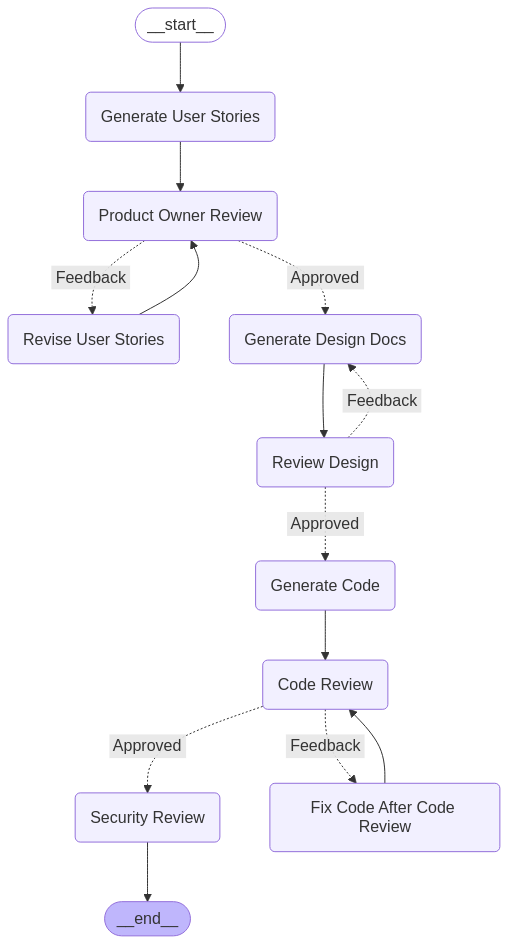

In [9]:
# Create the workflow
workflow = StateGraph(State)

# Add Nodes
workflow.add_node("Generate User Stories", auto_generate_user_stories)
workflow.add_node("Product Owner Review", product_owner_review)
workflow.add_node("Revise User Stories", revise_user_stories)
workflow.add_node("Generate Design Docs", create_design_docs)
workflow.add_node("Review Design", design_review)
workflow.add_node("Generate Code", generate_code)
workflow.add_node("Code Review", code_review)
workflow.add_node("Security Review", security_review)
workflow.add_node("Fix Code After Code Review", fix_code_after_review)

# Add Edges
workflow.add_edge(START, "Generate User Stories")
workflow.add_edge("Generate User Stories","Product Owner Review")
workflow.add_conditional_edges("Product Owner Review",
  lambda state: "Approved" if "Approved" in state.get("feedback") or state.get("review_user_story_count") >= 1 else "Feedback" ,
 {
    "Approved": "Generate Design Docs",
    "Feedback": "Revise User Stories"
})
workflow.add_edge("Revise User Stories", "Product Owner Review")
workflow.add_edge("Generate Design Docs", "Review Design")
workflow.add_conditional_edges("Review Design",
  lambda state: "Approved" if ("Approved" in state.get("product_feedback") or state.get("review_product_design_count") >= 1) else "Feedback",
 {
    "Approved": "Generate Code",
    "Feedback": "Generate Design Docs"
})
workflow.add_edge("Generate Code", "Code Review")
workflow.add_conditional_edges("Code Review",
  lambda state: "Approved" if ("Approved" in state.get("code_feedback") or state.get("review_code_count") >= 1) else "Feedback",
  {
    "Approved": "Security Review",
    "Feedback": "Fix Code After Code Review"
})
workflow.add_edge("Fix Code After Code Review", "Code Review")

workflow.add_edge("Security Review", END)
# Compile the graph
graph = workflow.compile()
#(graph.get_graph().print_ascii())
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
result = graph.invoke({"requirements": "I want to train a machine learning model end to end",
                      "review_user_story_count": 0,
                      "review_product_design_count":0,
                      "review_code_count" :0,
                      "product_feedback": ""})

----- Generating User Stories -----
----- Product Owner Review -----
----- Create Design Documents -----
----- Product Design Review -----
----- Generating Code -----
----- Code Review -----


In [ ]:
from IPython.display import Markdown
#Markdown(result['user_stories'])
#Markdown(result['feedback'])
Markdown(result['design_doc'])
#Markdown(result['code'])

### Design Documentation

---

#### #1. FUNCTIONAL DESIGN

##### 1.1 Overview

The system is designed to facilitate the machine learning lifecycle, from data collection and preprocessing to model training, validation, and deployment. This document outlines the functional and technical design to meet the requirements defined by approved user stories.

##### 1.2 Actors and User Roles

- **Machine Learning Engineer**: Responsible for gathering data, preprocessing, model selection, training, validation, and deployment.
- **System Admin**: Responsible for system maintenance, monitoring, and security.
- **End User**: Interacts with the deployed model to make predictions.

##### 1.3 Feature Breakdown

- **Data Collection and Preprocessing (US-001)**
  - Data Gathering
  - Data Cleaning
  - Data Normalization and Transformation
- **Model Configuration (US-002)**
  - Model Selection
  - Hyperparameter Tuning
  - Model Architecture Definition
- **Model Training (US-003)**
  - Training Process
  - Overfitting/Underfitting Monitoring
  - Performance Evaluation
- **Model Validation (US-004)**
  - Validation Dataset Preparation
  - Performance Metrics Calculation
  - Model Generalization Evaluation
- **Model Deployment (US-005)**
  - Model Packaging
  - Deployment to Production Environment
  - Real-time Prediction Service

##### 1.4 User Flows

1. **Machine Learning Engineer**
   - Gathers and preprocesses data
   - Selects and configures model
   - Trains and validates model
   - Deploys model to production

2. **End User**
   - Interacts with the deployed model via API
   - Receives real-time predictions

##### 1.5 UI/UX Considerations

- **Dashboard for Machine Learning Engineer**: A web-based interface for data and model management, including interactive visualizations of data and model performance.
- **API Documentation**: Comprehensive documentation for the deployment API, with examples and explanations.

##### 1.6 Business Rules

- Data must be preprocessed before being used for model training.
- Hyperparameters must be tuned before training.
- Model validation must be performed using a separate dataset.
- Deployment must include a secure API for real-time predictions.

---

#### #2. TECHNICAL DESIGN

##### 2.1 Architecture Overview

The system will be designed using a microservices architecture, with distinct services for data handling, model training, validation, and deployment. This architecture supports scalability, maintainability, and separation of concerns.

##### 2.2 System Components

- **Data Service**: Handles data collection, cleaning, and preprocessing.
- **Model Configuration Service**: Manages model selection, hyperparameter tuning, and model architecture configuration.
- **Training Service**: Manages the training process, including monitoring and evaluation.
- **Validation Service**: Manages the validation process to ensure the model generalizes well.
- **Deployment Service**: Packages and deploys the model to a production environment.
- **Prediction Service**: Exposes an API for real-time predictions.

##### 2.3 Data Model

- **Data Entity**: Represents raw data, including attributes such as source, timestamp, and data type.
- **ProcessedData Entity**: Represents cleaned and transformed data, with attributes like preprocessing method and normalization type.
- **Model Entity**: Represents the selected model, including attributes for type, hyperparameters, and configuration.
- **TrainingMetadata Entity**: Stores metadata about the training process, including performance metrics and training status.
- **ValidationMetadata Entity**: Stores metadata about the validation process, including performance metrics and validation status.
- **Deployment Entity**: Represents the deployed model, including deployment status and version information.

##### 2.4 API Design

- **Data Service API**: Endpoints for uploading, cleaning, and transforming data.
- **Model Configuration API**: Endpoints for selecting and configuring a model.
- **Training API**: Endpoints for initiating and monitoring the training process.
- **Validation API**: Endpoints for initiating and monitoring the validation process.
- **Deployment API**: Endpoints for packaging and deploying the model.
- **Prediction API**: Endpoints for real-time predictions.

##### 2.5 Security Considerations

- **Authentication**: Implement OAuth2 for secure access to APIs.
- **Authorization**: Role-based access control (RBAC) to restrict access to sensitive operations.
- **Data Protection**: Implement encryption for data at rest and in transit using TLS/SSL.

##### 2.6 Performance Considerations

- **Scalability**: Use cloud-native technologies to scale services horizontally.
- **Efficiency**: Optimize data processing and model training with parallel processing and caching.
- **Optimization**: Use efficient algorithms and data structures to minimize computational overhead.

##### 2.7 Error Handling Strategy

- Implement robust error handling in each service to ensure reliability and maintainability.
- Use custom exceptions and error codes for different types of errors.

##### 2.8 Logging and Monitoring

- **Logging**: Implement centralized logging with tools like ELK Stack (Elasticsearch, Logstash, Kibana) for monitoring and troubleshooting.
- **Monitoring**: Use tools like Prometheus and Grafana for real-time system monitoring.

---

### Conclusion

This design document provides a comprehensive overview of the system's functional and technical design, ensuring that the system can efficiently handle the complete machine learning lifecycle from data gathering to real-time predictions.